**SVM & Naive bayes**

Q1.What is a Support Vector Machine (SVM)?
 >- SVM (Support Vector Machine) is a supervised ML algorithm used for classification and regression. It finds the optimal hyperplane that separates data points into classes with maximum margin.

Q2.What is the difference between Hard Margin and Soft Margin SVM?
 >- Hard Margin: No misclassification allowed (only for perfectly separable data)

   * Soft Margin: Allows some errors using slack variables (real-world data)

Q3.What is the mathematical intuition behind SVM?

>- SVM maximizes margin:

Margin

	​        * Margin = \frac{2}{\|w\|


Objective:
         
         \min \frac{1}{2} \|w\|^2

	​

Q4.What is the role of Lagrange Multipliers in SVM?

 >- Used to convert constrained optimization into dual form and identify support vectors efficiently.

Q5.What are Support Vectors in SVM?

  >- Data points closest to decision boundary that influence hyperplane.

Q6.What is a Support Vector Classifier (SVC)?
 >- Support Vector Classifier → used for classification tasks.

Q7.What is a Support Vector Regressor (SVR)?

  >- Support Vector Regressor → used for regression problems.

Q8.What is the Kernel Trick in SVM?

  >- Transforms data into higher dimensions to make it linearly separable without explicit computation.

Q9.Compare Linear Kernel, Polynomial Kernel, and RBF Kernel?

  >- Linear → simple data

  Polynomial → curved boundary

  RBF → complex, nonlinear

Q10.What is the effect of the C parameter in SVM?

  >- High C → low error, overfitting

     Low C → more margin, underfitting

Q11.What is the role of the Gamma parameter in RBF Kernel SVM?

   >- High gamma → complex boundary

  Low gamma → smooth boundary

Q12.What is the Naïve Bayes classifier, and why is it called "Naïve"

  >- Probabilistic classifier based on Bayes theorem with independence assumption.

Q13.What is Bayes’ Theorem?

        P(A∣B)=P(B)P(B∣A)P(A)
	​

Q14.Explain the differences between Gaussian Naïve Bayes, Multinomial Naïve Bayes, and Bernoulli Naïve Bayes?

  >- Gaussian → continuous data

  Multinomial → text counts

  Bernoulli → binary features

Q15.When should you use Gaussian Naïve Bayes over other variants?

 >- When data is continuous and normally distributed.

Q16.What are the key assumptions made by Naïve BayeS?

   >- Feature independence

  * Equal importance of features

Q17.What are the advantages and disadvantages of Naïve Bayes?

   >- **Advantages**

(1)Fast

(2) Works well with small data

 **Disadvantages**

(1)Assumption rarely true

(2)Lower accuracy sometimes

Q18.Why is Naïve Bayes a good choice for text classification?

  >- Handles high-dimensional sparse data efficiently.

Q19.Compare SVM and Naïve Bayes for classification tasks?

**Feature**	             **SVM**                  **Naive Bayes**

   Speed             	    Slow	                     Fast

   Accuracy	              High	                   Moderate

  Data size          	   Medium	                     Large


Q20.How does Laplace Smoothing help in Naïve Bayes?

 >- Prevents zero probability:
    
		𝙋=count+1\total+n
	​
\

In [ ]:
#21.Write a Python program to train an SVM Classifier on the Iris dataset and evaluate accuracy

# Import required libraries
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data      # Features
y = iris.target    # Labels

# Split dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create SVM classifier (using linear kernel)
svm_model = SVC(kernel='linear')

# Train the model
svm_model.fit(X_train, y_train)

# Make predictions
y_pred = svm_model.predict(X_test)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Print results
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [ ]:
#22.Write a Python program to train two SVM classifiers with Linear and RBF kernels on the Wine dataset, then compare their accuracies

from sklearn.datasets import load_wine
from sklearn.svm import SVC

data = load_wine()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target)

linear = SVC(kernel='linear')
rbf = SVC(kernel='rbf')

linear.fit(X_train, y_train)
rbf.fit(X_train, y_train)

print("Linear:", linear.score(X_test, y_test))
print("RBF:", rbf.score(X_test, y_test))


Linear: 0.9555555555555556
RBF: 0.6666666666666666


In [ ]:
#23.Write a Python program to train an SVM Regressor (SVR) on a housing dataset and evaluate it using Mean Squared Error (MSE)

# Import required libraries
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# Load the housing dataset
housing = fetch_california_housing()
X = housing.data
y = housing.target

# Split dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling (important for SVR)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create SVR model (RBF kernel)
svr_model = SVR(kernel='rbf')

# Train the model
svr_model.fit(X_train, y_train)

# Make predictions
y_pred = svr_model.predict(X_test)

# Evaluate using Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Print results
print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 0.3570026426754463


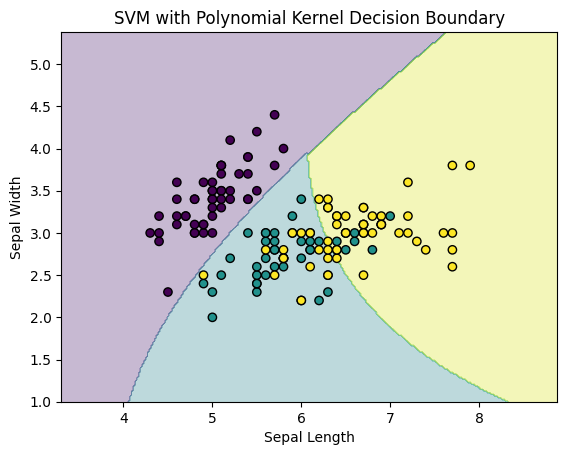

In [ ]:
#24.Write a Python program to train an SVM Classifier with a Polynomial Kernel and visualize the decision boundary

# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC

# Load Iris dataset
iris = datasets.load_iris()

# Use only two features for visualization (sepal length & sepal width)
X = iris.data[:, :2]
y = iris.target

# Train SVM with Polynomial kernel
model = SVC(kernel='poly', degree=3, C=1)
model.fit(X, y)

# Create mesh grid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

# Predict for each point in mesh
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.contourf(xx, yy, Z, alpha=0.3)

# Plot data points
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')

# Labels and title
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("SVM with Polynomial Kernel Decision Boundary")

plt.show()


In [ ]:
#25.Write a Python program to train a Gaussian Naïve Bayes classifier on the Breast Cancer dataset and evaluate accuracy

# Import required libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the Breast Cancer dataset
data = load_breast_cancer()
X = data.data      # Features
y = data.target    # Labels

# Split dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Gaussian Naïve Bayes model
model = GaussianNB()

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Print results
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9736842105263158

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.93      0.96        43
           1       0.96      1.00      0.98        71

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


Confusion Matrix:
 [[40  3]
 [ 0 71]]


In [ ]:
#26.Write a Python program to train a Multinomial Naïve Bayes classifier for text classification using the 20 Newsgroups dataset.

# Import required libraries
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Load dataset (subset for faster execution)
categories = ['alt.atheism', 'comp.graphics', 'sci.space', 'talk.politics.misc']

data = fetch_20newsgroups(subset='all', categories=categories)

X = data.data      # Text data
y = data.target    # Labels

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Convert text data into numerical features using CountVectorizer
vectorizer = CountVectorizer(stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Create Multinomial Naïve Bayes model
model = MultinomialNB()

# Train the model
model.fit(X_train_vec, y_train)

# Make predictions
y_pred = model.predict(X_test_vec)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Print results
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9702970297029703

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       163
           1       0.97      0.98      0.97       203
           2       0.96      0.97      0.97       191
           3       0.97      0.95      0.96       150

    accuracy                           0.97       707
   macro avg       0.97      0.97      0.97       707
weighted avg       0.97      0.97      0.97       707



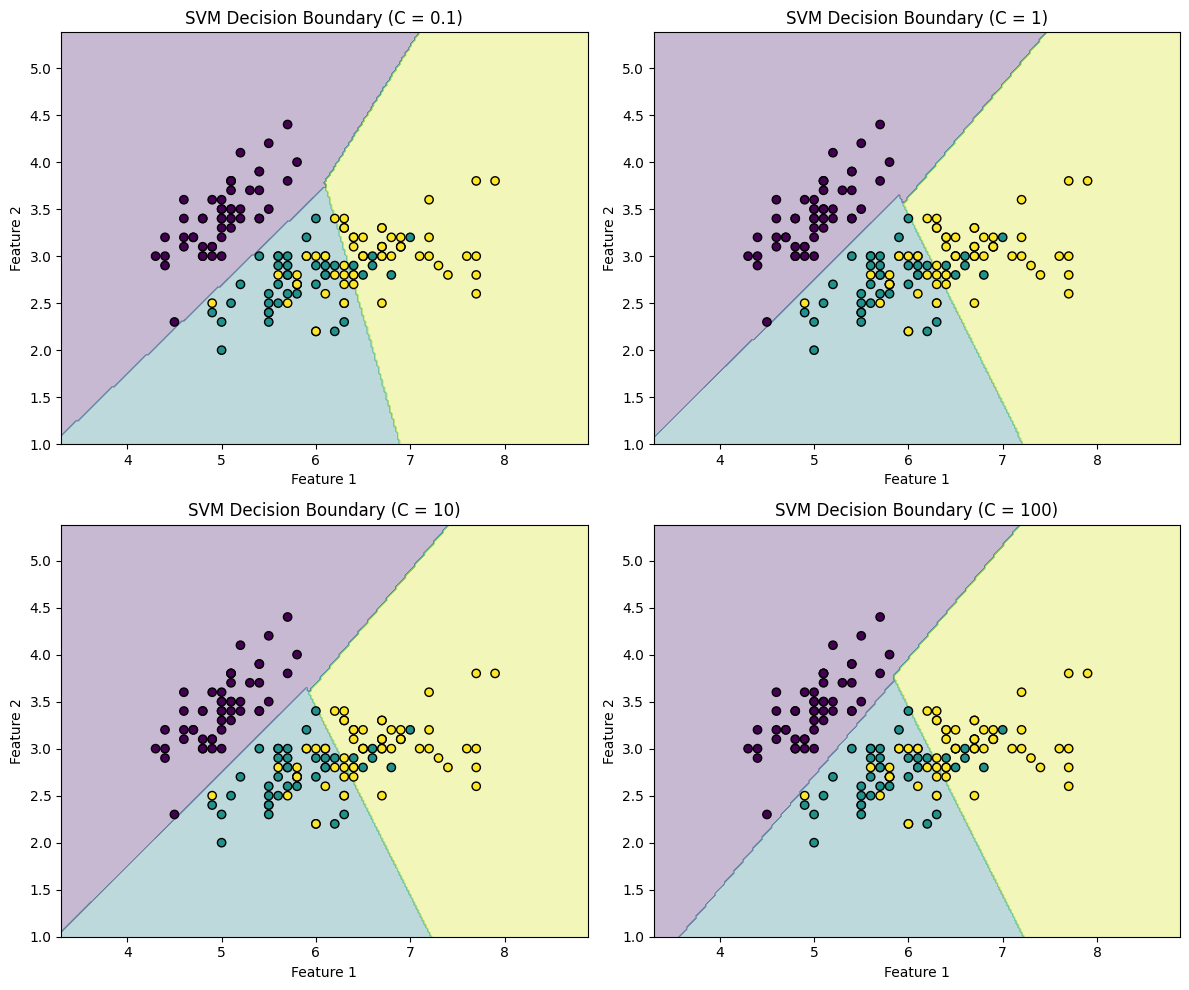

In [ ]:
#27.Write a Python program to train an SVM Classifier with different C values and compare the decision boundaries visually

# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC

# Load Iris dataset
iris = datasets.load_iris()

# Use only two features for visualization
X = iris.data[:, :2]
y = iris.target

# Different C values to compare
C_values = [0.1, 1, 10, 100]

# Create mesh grid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

# Plot decision boundaries for each C
plt.figure(figsize=(12, 10))

for i, C in enumerate(C_values):
    # Train SVM model
    model = SVC(kernel='linear', C=C)
    model.fit(X, y)

    # Predict on mesh grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot subplot
    plt.subplot(2, 2, i + 1)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')

    plt.title(f"SVM Decision Boundary (C = {C})")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

plt.tight_layout()
plt.show()

In [ ]:
#28.Write a Python program to train a Bernoulli Naïve Bayes classifier for binary classification on a dataset with binary features

# Import required libraries
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create a sample binary dataset (0/1 features)
# Each row = sample, each column = binary feature
X = np.array([
    [1, 0, 1, 0],
    [1, 1, 1, 0],
    [0, 0, 1, 1],
    [0, 1, 0, 1],
    [1, 0, 0, 0],
    [0, 1, 1, 1],
    [1, 1, 0, 1],
    [0, 0, 0, 0]
])

# Binary target labels (0 or 1)
y = np.array([1, 1, 0, 0, 1, 0, 1, 0])

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Create Bernoulli Naïve Bayes model
model = BernoulliNB()

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)

# Print results
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2


Confusion Matrix:
 [[1 0]
 [0 1]]


In [ ]:
#29. Write a Python program to apply feature scaling before training an SVM model and compare results with unscaled data

# Import required libraries
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create a sample binary dataset (0/1 features)
# Each row = sample, each column = binary feature
X = np.array([
    [1, 0, 1, 0],
    [1, 1, 1, 0],
    [0, 0, 1, 1],
    [0, 1, 0, 1],
    [1, 0, 0, 0],
    [0, 1, 1, 1],
    [1, 1, 0, 1],
    [0, 0, 0, 0]
])

# Binary target labels (0 or 1)
y = np.array([1, 1, 0, 0, 1, 0, 1, 0])

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Create Bernoulli Naïve Bayes model
model = BernoulliNB()

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)

# Print results
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2


Confusion Matrix:
 [[1 0]
 [0 1]]


In [ ]:
#29.Write a Python program to train a Gaussian Naïve Bayes model and compare the predictions before and after Laplace Smoothing

# Import required libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import numpy as np

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Model WITHOUT smoothing
# -----------------------------
model_no_smooth = GaussianNB(var_smoothing=0)  # No smoothing
model_no_smooth.fit(X_train, y_train)

y_pred_no = model_no_smooth.predict(X_test)
acc_no = accuracy_score(y_test, y_pred_no)

# -----------------------------
# Model WITH smoothing
# -----------------------------
model_smooth = GaussianNB(var_smoothing=1e-9)  # Default smoothing
model_smooth.fit(X_train, y_train)

y_pred_smooth = model_smooth.predict(X_test)
acc_smooth = accuracy_score(y_test, y_pred_smooth)

# -----------------------------
# Compare results
# -----------------------------
print("Accuracy WITHOUT smoothing:", acc_no)
print("Accuracy WITH smoothing:", acc_smooth)

# Compare predictions
print("\nFirst 10 Predictions (No Smoothing):", y_pred_no[:10])
print("First 10 Predictions (With Smoothing):", y_pred_smooth[:10])

# Count differences
difference = np.sum(y_pred_no != y_pred_smooth)
print("\nNumber of different predictions:", difference)

Accuracy WITHOUT smoothing: 0.9649122807017544
Accuracy WITH smoothing: 0.9736842105263158

First 10 Predictions (No Smoothing): [1 0 0 1 1 0 0 0 0 1]
First 10 Predictions (With Smoothing): [1 0 0 1 1 0 0 0 1 1]

Number of different predictions: 1


In [ ]:
#31.Write a Python program to train an SVM Classifier and use GridSearchCV to tune the hyperparameters (C, gamma, kernel)
# Import required libraries
from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Load dataset (Iris)
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define SVM model
svm = SVC()

# Define hyperparameter grid
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.001],
    'kernel': ['linear', 'rbf', 'poly']
}

# Apply GridSearchCV
grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,           # 5-fold cross-validation
    scoring='accuracy',
    verbose=1
)

# Train model with grid search
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

# Best model
best_model = grid_search.best_estimator_

# Make predictions
y_pred = best_model.predict(X_test)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Print results
print("Test Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Test Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [ ]:
#32.Write a Python program to train an SVM Classifier on an imbalanced dataset and apply class weighting and check it improve accuracy

# Import required libraries
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Create an imbalanced dataset
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_classes=2,
    weights=[0.9, 0.1],   # 90% of class 0, 10% of class 1
    random_state=42
)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Model WITHOUT class weighting
# -----------------------------
model_no_weight = SVC(kernel='rbf')
model_no_weight.fit(X_train, y_train)

y_pred_no = model_no_weight.predict(X_test)
acc_no = accuracy_score(y_test, y_pred_no)

print("WITHOUT Class Weighting")
print("Accuracy:", acc_no)
print(classification_report(y_test, y_pred_no))

# -----------------------------
# Model WITH class weighting
# -----------------------------
model_weighted = SVC(kernel='rbf', class_weight='balanced')
model_weighted.fit(X_train, y_train)

y_pred_weighted = model_weighted.predict(X_test)
acc_weighted = accuracy_score(y_test, y_pred_weighted)

print("\nWITH Class Weighting")
print("Accuracy:", acc_weighted)
print(classification_report(y_test, y_pred_weighted))

WITHOUT Class Weighting
Accuracy: 0.92
              precision    recall  f1-score   support

           0       0.92      0.99      0.96       175
           1       0.91      0.40      0.56        25

    accuracy                           0.92       200
   macro avg       0.91      0.70      0.76       200
weighted avg       0.92      0.92      0.91       200


WITH Class Weighting
Accuracy: 0.89
              precision    recall  f1-score   support

           0       0.96      0.91      0.94       175
           1       0.54      0.76      0.63        25

    accuracy                           0.89       200
   macro avg       0.75      0.83      0.78       200
weighted avg       0.91      0.89      0.90       200



In [ ]:
#33.Write a Python program to implement a Naïve Bayes classifier for spam detection using email data?

# Import required libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Sample email dataset (you can replace this with a CSV file)
data = {
    'email': [
        "Win a free lottery now",
        "Hello friend how are you",
        "Limited offer claim your prize",
        "Meeting scheduled tomorrow",
        "Congratulations you won cash",
        "Let's have lunch today",
        "Free coupons available now",
        "Project report attached"
    ],
    'label': [1, 0, 1, 0, 1, 0, 1, 0]  # 1 = spam, 0 = not spam
}

# Create DataFrame
df = pd.DataFrame(data)

# Split features and labels
X = df['email']
y = df['label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Convert text to numerical features
vectorizer = CountVectorizer(stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train Naïve Bayes model
model = MultinomialNB()
model.fit(X_train_vec, y_train)

# Make predictions
y_pred = model.predict(X_test_vec)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Test with new email
new_email = ["Congratulations! You have won a free ticket"]
new_email_vec = vectorizer.transform(new_email)
prediction = model.predict(new_email_vec)

print("\nNew Email Prediction:", "Spam" if prediction[0] == 1 else "Not Spam")

Accuracy: 0.0

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       2.0
           1       0.00      0.00      0.00       0.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0


Confusion Matrix:
 [[0 2]
 [0 0]]

New Email Prediction: Spam


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [ ]:
#34.Write a Python program to train an SVM Classifier and a Naïve Bayes Classifier on the same dataset and compare their accuracy

# Import required libraries
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Load dataset (Iris)
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Train SVM Classifier
# -----------------------------
svm_model = SVC(kernel='rbf')
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)
svm_accuracy = accuracy_score(y_test, y_pred_svm)

# -----------------------------
# Train Naïve Bayes Classifier
# -----------------------------
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)
nb_accuracy = accuracy_score(y_test, y_pred_nb)

# -----------------------------
# Compare Results
# -----------------------------
print("SVM Accuracy:", svm_accuracy)
print("Naïve Bayes Accuracy:", nb_accuracy)

# Better model
if svm_accuracy > nb_accuracy:
    print("\nSVM performs better on this dataset.")
elif nb_accuracy > svm_accuracy:
    print("\nNaïve Bayes performs better on this dataset.")
else:
    print("\nBoth models perform equally.")

SVM Accuracy: 1.0
Naïve Bayes Accuracy: 1.0

Both models perform equally.


In [ ]:
#35.Write a Python program to perform feature selection before training a Naïve Bayes classifier and compare results

# Import required libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Scale data (required for chi2 - no negative values)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# -----------------------------
# Without Feature Selection
# -----------------------------
model_full = GaussianNB()
model_full.fit(X_train, y_train)

y_pred_full = model_full.predict(X_test)
acc_full = accuracy_score(y_test, y_pred_full)

# -----------------------------
# With Feature Selection
# -----------------------------
selector = SelectKBest(score_func=chi2, k=10)  # select top 10 features
X_train_sel = selector.fit_transform(X_train, y_train)
X_test_sel = selector.transform(X_test)

model_sel = GaussianNB()
model_sel.fit(X_train_sel, y_train)

y_pred_sel = model_sel.predict(X_test_sel)
acc_sel = accuracy_score(y_test, y_pred_sel)

# -----------------------------
# Compare Results
# -----------------------------
print("Accuracy WITHOUT feature selection:", acc_full)
print("Accuracy WITH feature selection:", acc_sel)

# Show selected feature indices
print("\nSelected feature indices:", selector.get_support(indices=True))

Accuracy WITHOUT feature selection: 0.9649122807017544
Accuracy WITH feature selection: 0.9736842105263158

Selected feature indices: [ 0  2  3  6  7 20 22 23 26 27]


In [ ]:
#36.Write a Python program to train an SVM Classifier using One-vs-Rest (OvR) and One-vs-One (OvO) strategies on the Wine dataset and compare their accuracy

# Import required libraries
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.metrics import accuracy_score

# Load Wine dataset
data = load_wine()
X = data.data
y = data.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# One-vs-Rest (OvR)
# -----------------------------
ovr_model = OneVsRestClassifier(SVC(kernel='rbf'))
ovr_model.fit(X_train, y_train)

y_pred_ovr = ovr_model.predict(X_test)
acc_ovr = accuracy_score(y_test, y_pred_ovr)

# -----------------------------
# One-vs-One (OvO)
# -----------------------------
ovo_model = OneVsOneClassifier(SVC(kernel='rbf'))
ovo_model.fit(X_train, y_train)

y_pred_ovo = ovo_model.predict(X_test)
acc_ovo = accuracy_score(y_test, y_pred_ovo)

# -----------------------------
# Compare Results
# -----------------------------
print("OvR Accuracy:", acc_ovr)
print("OvO Accuracy:", acc_ovo)

# Better model
if acc_ovr > acc_ovo:
    print("\nOne-vs-Rest performs better.")
elif acc_ovo > acc_ovr:
    print("\nOne-vs-One performs better.")
else:
    print("\nBoth strategies perform equally.")

OvR Accuracy: 0.7777777777777778
OvO Accuracy: 0.8333333333333334

One-vs-One performs better.


In [ ]:
#37.Write a Python program to train an SVM Classifier using Linear, Polynomial, and RBF kernels on the Breast Cancer dataset and compare their accuracy

# Import required libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Linear Kernel
# -----------------------------
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

y_pred_linear = svm_linear.predict(X_test)
acc_linear = accuracy_score(y_test, y_pred_linear)

# -----------------------------
# Polynomial Kernel
# -----------------------------
svm_poly = SVC(kernel='poly', degree=3)
svm_poly.fit(X_train, y_train)

y_pred_poly = svm_poly.predict(X_test)
acc_poly = accuracy_score(y_test, y_pred_poly)

# -----------------------------
# RBF Kernel
# -----------------------------
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)
acc_rbf = accuracy_score(y_test, y_pred_rbf)

# -----------------------------
# Compare Results
# -----------------------------
print("Linear Kernel Accuracy:", acc_linear)
print("Polynomial Kernel Accuracy:", acc_poly)
print("RBF Kernel Accuracy:", acc_rbf)

# Find best kernel
best_kernel = max(
    [("Linear", acc_linear), ("Polynomial", acc_poly), ("RBF", acc_rbf)],
    key=lambda x: x[1]
)

print("\nBest Performing Kernel:", best_kernel[0])

Linear Kernel Accuracy: 0.956140350877193
Polynomial Kernel Accuracy: 0.9473684210526315
RBF Kernel Accuracy: 0.9473684210526315

Best Performing Kernel: Linear


In [ ]:
#38.Write a Python program to train an SVM Classifier using Stratified K-Fold Cross-Validation and compute the average accuracy

# Import required libraries
from sklearn import datasets
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import numpy as np

# Load dataset (Iris dataset as example)
data = datasets.load_iris()
X = data.data
y = data.target

# Initialize SVM classifier
model = SVC(kernel='rbf', C=1, gamma='scale')

# Initialize Stratified K-Fold
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

accuracies = []

# Perform Stratified K-Fold Cross Validation
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Train the model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Evaluate accuracy
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

# Compute average accuracy
average_accuracy = np.mean(accuracies)

# Print results
print("Accuracies for each fold:", accuracies)
print("Average Accuracy:", average_accuracy)

Accuracies for each fold: [1.0, 0.9666666666666667, 0.9333333333333333, 1.0, 0.9333333333333333]
Average Accuracy: 0.9666666666666668


In [ ]:
#39.Write a Python program to train a Naïve Bayes classifier using different prior probabilities and compare performance

# Import required libraries
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Load dataset (Iris dataset)
data = datasets.load_iris()
X = data.data
y = data.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Define different prior probabilities
priors_list = [
    None,                     # Default (learned from data)
    [0.33, 0.33, 0.34],       # Nearly equal priors
    [0.6, 0.2, 0.2],          # Biased toward class 0
    [0.2, 0.6, 0.2],          # Biased toward class 1
    [0.2, 0.2, 0.6]           # Biased toward class 2
]

# Train and evaluate model for each prior
results = []

for priors in priors_list:
    # Initialize model with given priors
    model = GaussianNB(priors=priors)

    # Train model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)

    results.append((priors, acc))

# Display results
print("Performance Comparison with Different Priors:\n")
for priors, acc in results:
    print(f"Priors: {priors} --> Accuracy: {acc:.4f}")

Performance Comparison with Different Priors:

Priors: None --> Accuracy: 0.9111
Priors: [0.33, 0.33, 0.34] --> Accuracy: 0.9111
Priors: [0.6, 0.2, 0.2] --> Accuracy: 0.9111
Priors: [0.2, 0.6, 0.2] --> Accuracy: 0.9111
Priors: [0.2, 0.2, 0.6] --> Accuracy: 0.9111


In [ ]:
#40.Write a Python program to perform Recursive Feature Elimination (RFE) before training an SVM Classifier and compare accuracy

# Import required libraries
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score

# Load dataset (Breast Cancer dataset)
data = datasets.load_breast_cancer()
X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# -------------------------------
# 1. Train SVM without RFE
# -------------------------------
model_full = SVC(kernel='linear')

model_full.fit(X_train, y_train)
y_pred_full = model_full.predict(X_test)

accuracy_full = accuracy_score(y_test, y_pred_full)

# -------------------------------
# 2. Apply RFE + Train SVM
# -------------------------------
# Select top N features
n_features = 10

svm = SVC(kernel='linear')

rfe = RFE(estimator=svm, n_features_to_select=n_features)
rfe.fit(X_train, y_train)

# Transform dataset
X_train_rfe = rfe.transform(X_train)
X_test_rfe = rfe.transform(X_test)

# Train SVM on selected features
model_rfe = SVC(kernel='linear')
model_rfe.fit(X_train_rfe, y_train)

y_pred_rfe = model_rfe.predict(X_test_rfe)

accuracy_rfe = accuracy_score(y_test, y_pred_rfe)

# -------------------------------
# Results
# -------------------------------
print("Accuracy without RFE:", round(accuracy_full, 4))
print("Accuracy with RFE:", round(accuracy_rfe, 4))

print("\nSelected Feature Indices:", rfe.get_support(indices=True))

Accuracy without RFE: 0.9532
Accuracy with RFE: 0.9591

Selected Feature Indices: [ 0  6 10 11 20 24 25 26 27 28]


In [ ]:
#41.Write a Python program to train an SVM Classifier and evaluate its performance using Precision, Recall, and F1-Score instead of accuracy

# Import required libraries
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# Load dataset (Breast Cancer dataset)
data = datasets.load_breast_cancer()
X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Train SVM classifier
model = SVC(kernel='rbf', C=1, gamma='scale')
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluate using Precision, Recall, F1-score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print results
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-Score:", round(f1, 4))

# Detailed classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Precision: 0.8889
Recall: 0.972
F1-Score: 0.9286

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.80      0.86        64
           1       0.89      0.97      0.93       107

    accuracy                           0.91       171
   macro avg       0.92      0.88      0.90       171
weighted avg       0.91      0.91      0.90       171



In [ ]:
#42.Write a Python program to train a Naïve Bayes Classifier and evaluate its performance using Log Loss (Cross-Entropy Loss)

# Import required libraries
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import log_loss

# Load dataset (Breast Cancer dataset)
data = datasets.load_breast_cancer()
X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Train Naïve Bayes classifier
model = GaussianNB()
model.fit(X_train, y_train)

# Predict probabilities (important for log loss)
y_prob = model.predict_proba(X_test)

# Compute Log Loss
loss = log_loss(y_test, y_prob)

# Print result
print("Log Loss (Cross-Entropy Loss):", round(loss, 4))

Log Loss (Cross-Entropy Loss): 0.3382


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



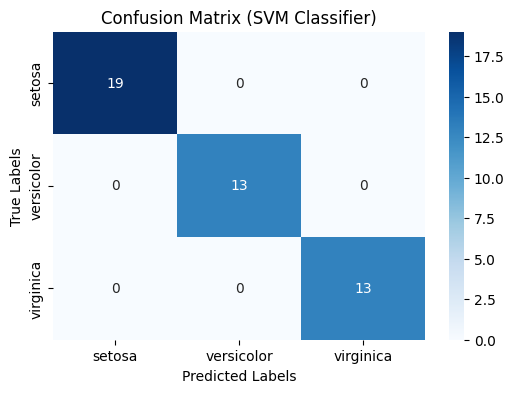

In [ ]:
#43.Write a Python program to train an SVM Classifier and visualize the Confusion Matrix using seaborn

# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report

# Load dataset (Iris dataset)
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train SVM Classifier
model = SVC(kernel='linear')
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Compute Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Print classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# Visualize Confusion Matrix using Seaborn
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix (SVM Classifier)")
plt.show()

In [ ]:
#44.Write a Python program to train an SVM Regressor (SVR) and evaluate its performance using Mean Absolute Error (MAE) instead of MSE

# Import libraries
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error

# Load dataset (California Housing)
data = fetch_california_housing()
X = data.data
y = data.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train SVR model
model = SVR(kernel='rbf')  # You can also try 'linear' or 'poly'
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Evaluate using Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)

# Print results
print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 0.8599506583445761


ROC-AUC Score: 0.9983622666229938


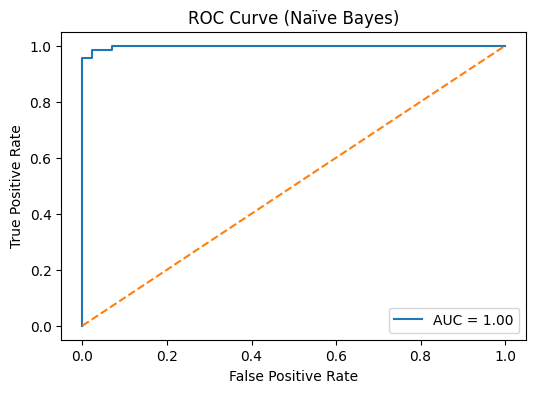

In [ ]:
#45.Write a Python program to train a Naïve Bayes classifier and evaluate its performance using the ROC-AUC score

# Import libraries
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Load dataset (Binary classification required for ROC-AUC)
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Naïve Bayes model
model = GaussianNB()
model.fit(X_train, y_train)

# Predict probabilities (important for ROC-AUC)
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC score
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

# Compute ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot ROC Curve
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # Random classifier line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Naïve Bayes)")
plt.legend()
plt.show()

Average Precision (AP): 0.9960990902415073


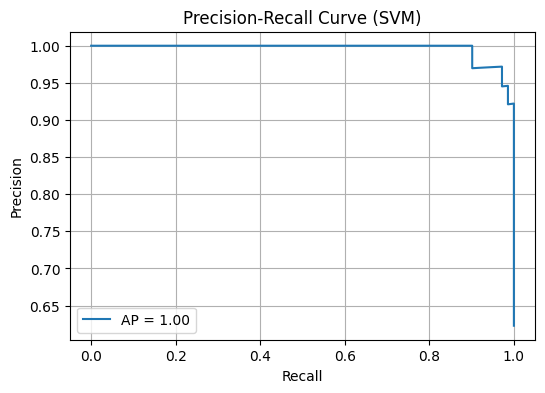

In [ ]:
#46.Write a Python program to train an SVM Classifier and visualize the Precision-Recall Curve.

# Import libraries
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import precision_recall_curve, average_precision_score

# Load dataset (binary classification)
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train SVM Classifier
model = SVC(kernel='rbf', probability=True)  # probability=True needed for PR curve
model.fit(X_train, y_train)

# Get predicted probabilities
y_scores = model.predict_proba(X_test)[:, 1]

# Compute Precision-Recall values
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# Compute Average Precision (AP)
ap_score = average_precision_score(y_test, y_scores)
print("Average Precision (AP):", ap_score)

# Plot Precision-Recall Curve
plt.figure(figsize=(6, 4))
plt.plot(recall, precision, label=f"AP = {ap_score:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (SVM)")
plt.legend()
plt.grid()
plt.show()